# Analiza skupa podataka – Garbage Classification

## Cilj

Cilj ovog notebook-a je izvršiti početnu analizu skupa podataka
Garbage Classification koji se koristi za klasifikaciju različitih
vrsta otpada pomoću konvolutivnih neuronskih mreža.

Analiza obuhvata:

- učitavanje i identifikaciju skupa podataka,
- identifikaciju klasa,
- broj slika po klasama,
- proveru formata i validnosti slika,
- analizu dimenzija slika,
- analizu balansa klasa,
- proveru duplikata,
- osnovnu statistiku RGB kanala,
- vizuelizaciju distribucije podataka,
- prikaz reprezentativnih primera iz svake klase.

Rezultati analize koristiće se za definisanje narednih koraka
u pripremi podataka i treniranju modela.

In [1]:
from pathlib import Path
import hashlib
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = False

print("Biblioteke su uspešno učitane.")

Biblioteke su uspešno učitane.


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed: {SEED}")

Random seed: 42


In [3]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "Garbage classification" / "Garbage classification"

print("Project root:")
print(PROJECT_ROOT)

print("\nDataset:")
print(DATA_DIR)

print("\nDataset postoji:", DATA_DIR.exists())

Project root:
c:\Users\PC\Garbage-Classification

Dataset:
c:\Users\PC\Garbage-Classification\data\raw\Garbage classification\Garbage classification

Dataset postoji: True


In [4]:
class_dirs = sorted([
    path for path in DATA_DIR.iterdir()
    if path.is_dir()
])

classes = [path.name for path in class_dirs]

print(f"Broj klasa: {len(classes)}")
print("\nKlase:")

for i, class_name in enumerate(classes, start=1):
    print(f"{i}. {class_name}")

Broj klasa: 6

Klase:
1. cardboard
2. glass
3. metal
4. paper
5. plastic
6. trash


In [5]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

records = []

for class_dir in class_dirs:
    for image_path in class_dir.rglob("*"):
        if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
            records.append({
                "filepath": str(image_path),
                "filename": image_path.name,
                "class": class_dir.name,
                "extension": image_path.suffix.lower()
            })

df = pd.DataFrame(records)

print(f"Ukupan broj pronađenih slika: {len(df):,}")
df.head()

Ukupan broj pronađenih slika: 2,527


,filepath,filename,class,extension
0,c:\Users\PC\Garbage-Classification\data\raw\Ga...,cardboard1.jpg,cardboard,.jpg
1,c:\Users\PC\Garbage-Classification\data\raw\Ga...,cardboard10.jpg,cardboard,.jpg
2,c:\Users\PC\Garbage-Classification\data\raw\Ga...,cardboard100.jpg,cardboard,.jpg
3,c:\Users\PC\Garbage-Classification\data\raw\Ga...,cardboard101.jpg,cardboard,.jpg
4,c:\Users\PC\Garbage-Classification\data\raw\Ga...,cardboard102.jpg,cardboard,.jpg


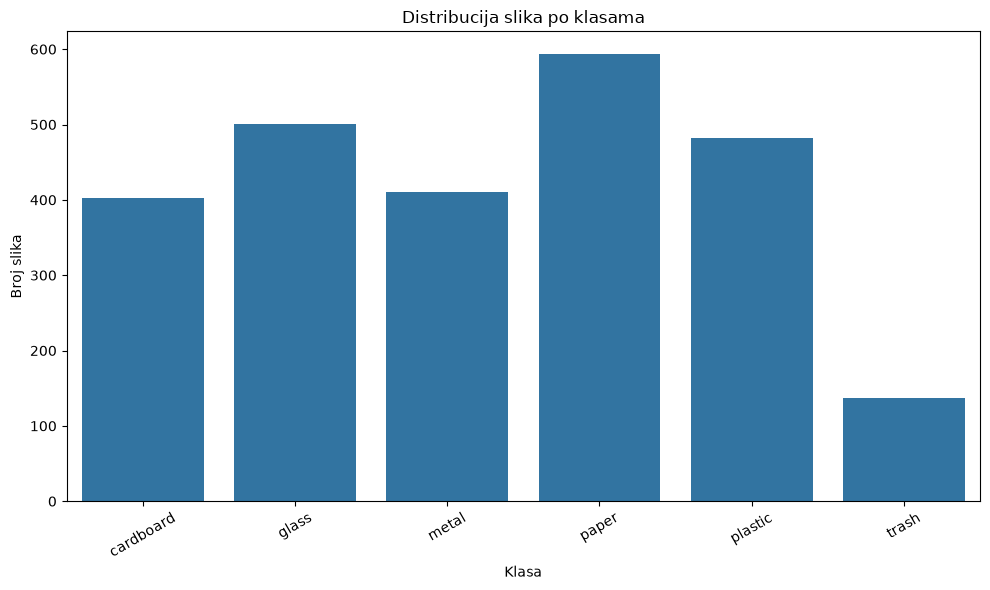

In [6]:
class_distribution = (
    df["class"]
    .value_counts()
    .sort_index()
)

class_distribution

plt.figure(figsize=(10, 6))

sns.barplot(
    x=class_distribution.index,
    y=class_distribution.values
)

plt.title("Distribucija slika po klasama")
plt.xlabel("Klasa")
plt.ylabel("Broj slika")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [7]:
distribution_table = pd.DataFrame({
    "Broj slika": class_distribution,
    "Procenat (%)": (
        class_distribution / len(df) * 100
    ).round(2)
})

distribution_table

,Broj slika,Procenat (%)
class,,
cardboard,403,15.95
glass,501,19.83
metal,410,16.22
paper,594,23.51
plastic,482,19.07
trash,137,5.42


In [9]:
extension_distribution = (
    df["extension"]
    .value_counts()
    .sort_index()
)

print("Distribucija formata slika:")
display(extension_distribution.to_frame("Broj slika"))

Distribucija formata slika:


,Broj slika
extension,
.jpg,2527


In [10]:
invalid_images = []

for filepath in df["filepath"]:
    try:
        with Image.open(filepath) as img:
            img.verify()
    except Exception as e:
        invalid_images.append({
            "filepath": filepath,
            "error": str(e)
        })

invalid_df = pd.DataFrame(invalid_images)

print(f"Broj neispravnih slika: {len(invalid_df)}")

if len(invalid_df) > 0:
    display(invalid_df.head(20))
else:
    print("Nisu pronađene neispravne slike.")

Broj neispravnih slika: 0
Nisu pronađene neispravne slike.


In [11]:
image_dimensions = []

for filepath in df["filepath"]:
    try:
        with Image.open(filepath) as img:
            width, height = img.size
            image_dimensions.append({
                "filepath": filepath,
                "width": width,
                "height": height,
                "aspect_ratio": round(width / height, 4),
                "mode": img.mode
            })
    except Exception:
        pass

dimensions_df = pd.DataFrame(image_dimensions)

dimensions_df.head()

,filepath,width,height,aspect_ratio,mode
0,c:\Users\PC\Garbage-Classification\data\raw\Ga...,512,384,1.3333,RGB
1,c:\Users\PC\Garbage-Classification\data\raw\Ga...,512,384,1.3333,RGB
2,c:\Users\PC\Garbage-Classification\data\raw\Ga...,512,384,1.3333,RGB
3,c:\Users\PC\Garbage-Classification\data\raw\Ga...,512,384,1.3333,RGB
4,c:\Users\PC\Garbage-Classification\data\raw\Ga...,512,384,1.3333,RGB


In [12]:
dimensions_df[["width", "height", "aspect_ratio"]].describe()

,width,height,aspect_ratio
count,2527.0,2527.0,2.527000e+03
mean,512.0,384.0,1.333300e+00
std,0.0,0.0,2.220886e-16
min,512.0,384.0,1.333300e+00
25%,512.0,384.0,1.333300e+00
50%,512.0,384.0,1.333300e+00
75%,512.0,384.0,1.333300e+00
max,512.0,384.0,1.333300e+00


In [13]:
dimension_distribution = (
    dimensions_df
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

dimension_distribution.head(20)

,width,height,count
0,512,384,2527


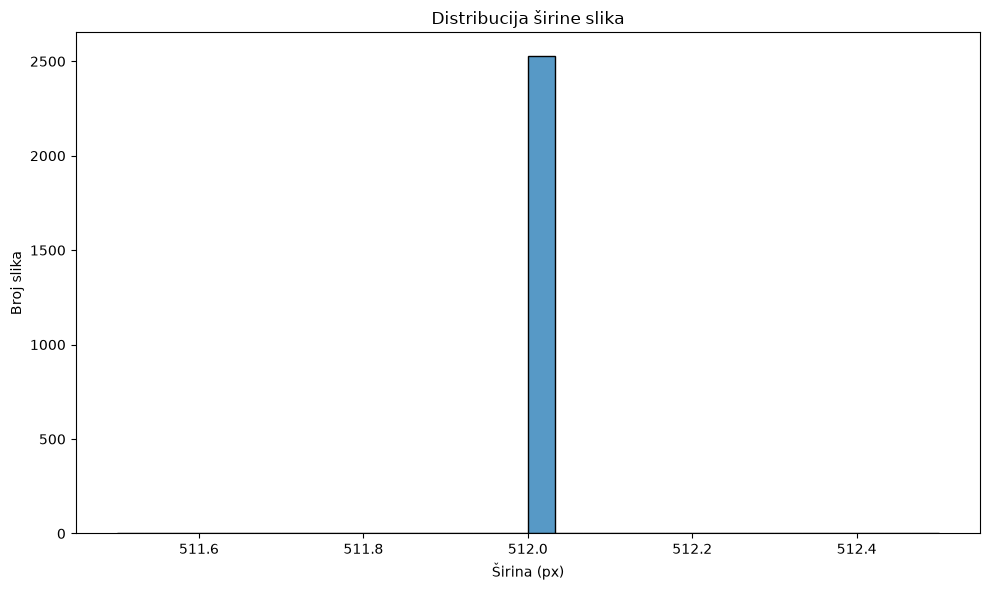

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=dimensions_df,
    x="width",
    bins=30
)

plt.title("Distribucija širine slika")
plt.xlabel("Širina (px)")
plt.ylabel("Broj slika")
plt.tight_layout()

plt.show()

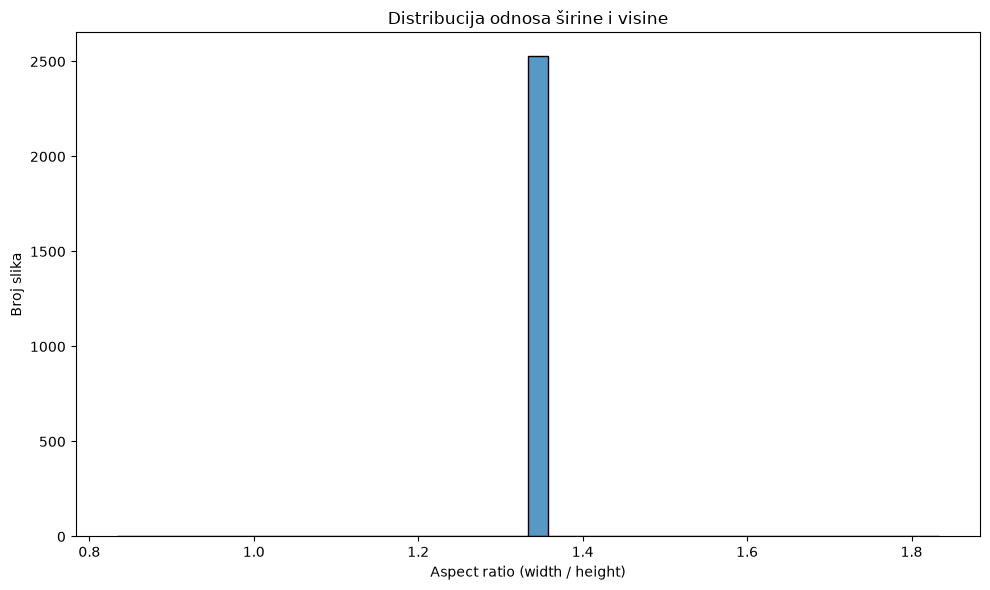

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=dimensions_df,
    x="aspect_ratio",
    bins=40
)

plt.title("Distribucija odnosa širine i visine")
plt.xlabel("Aspect ratio (width / height)")
plt.ylabel("Broj slika")
plt.tight_layout()

plt.show()

In [16]:
pixel_statistics = []

for filepath in df["filepath"]:
    try:
        with Image.open(filepath).convert("RGB") as img:
            arr = np.asarray(img, dtype=np.float32)

            pixel_statistics.append({
                "filepath": filepath,
                "mean_R": arr[:, :, 0].mean(),
                "mean_G": arr[:, :, 1].mean(),
                "mean_B": arr[:, :, 2].mean(),
                "std_R": arr[:, :, 0].std(),
                "std_G": arr[:, :, 1].std(),
                "std_B": arr[:, :, 2].std()
            })
    except Exception:
        pass

pixel_stats_df = pd.DataFrame(pixel_statistics)

pixel_stats_df.head()

,filepath,mean_R,mean_G,mean_B,std_R,std_G,std_B
0,c:\Users\PC\Garbage-Classification\data\raw\Ga...,189.004623,155.501816,126.715797,34.503559,31.122360,28.974699
1,c:\Users\PC\Garbage-Classification\data\raw\Ga...,186.063965,163.299988,142.507599,41.514484,38.172630,36.154049
2,c:\Users\PC\Garbage-Classification\data\raw\Ga...,186.098022,181.422318,176.548279,40.463074,46.309082,50.502777
3,c:\Users\PC\Garbage-Classification\data\raw\Ga...,148.703232,127.276512,102.968956,62.842384,70.214066,75.762001
4,c:\Users\PC\Garbage-Classification\data\raw\Ga...,173.029358,163.703568,152.382507,38.524673,46.859558,55.952560


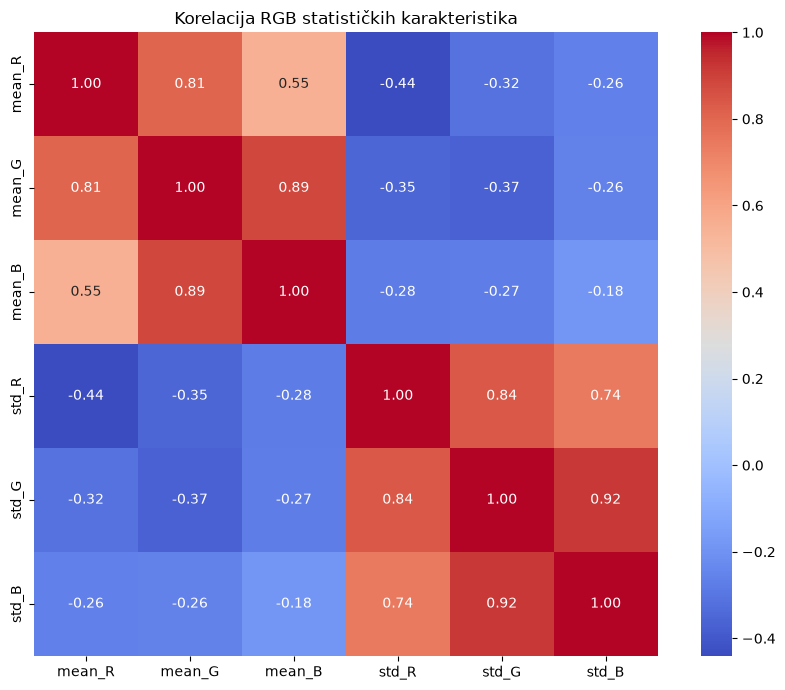

In [17]:
correlation_columns = [
    "mean_R",
    "mean_G",
    "mean_B",
    "std_R",
    "std_G",
    "std_B"
]

correlation_matrix = pixel_stats_df[correlation_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Korelacija RGB statističkih karakteristika")
plt.tight_layout()

plt.show()

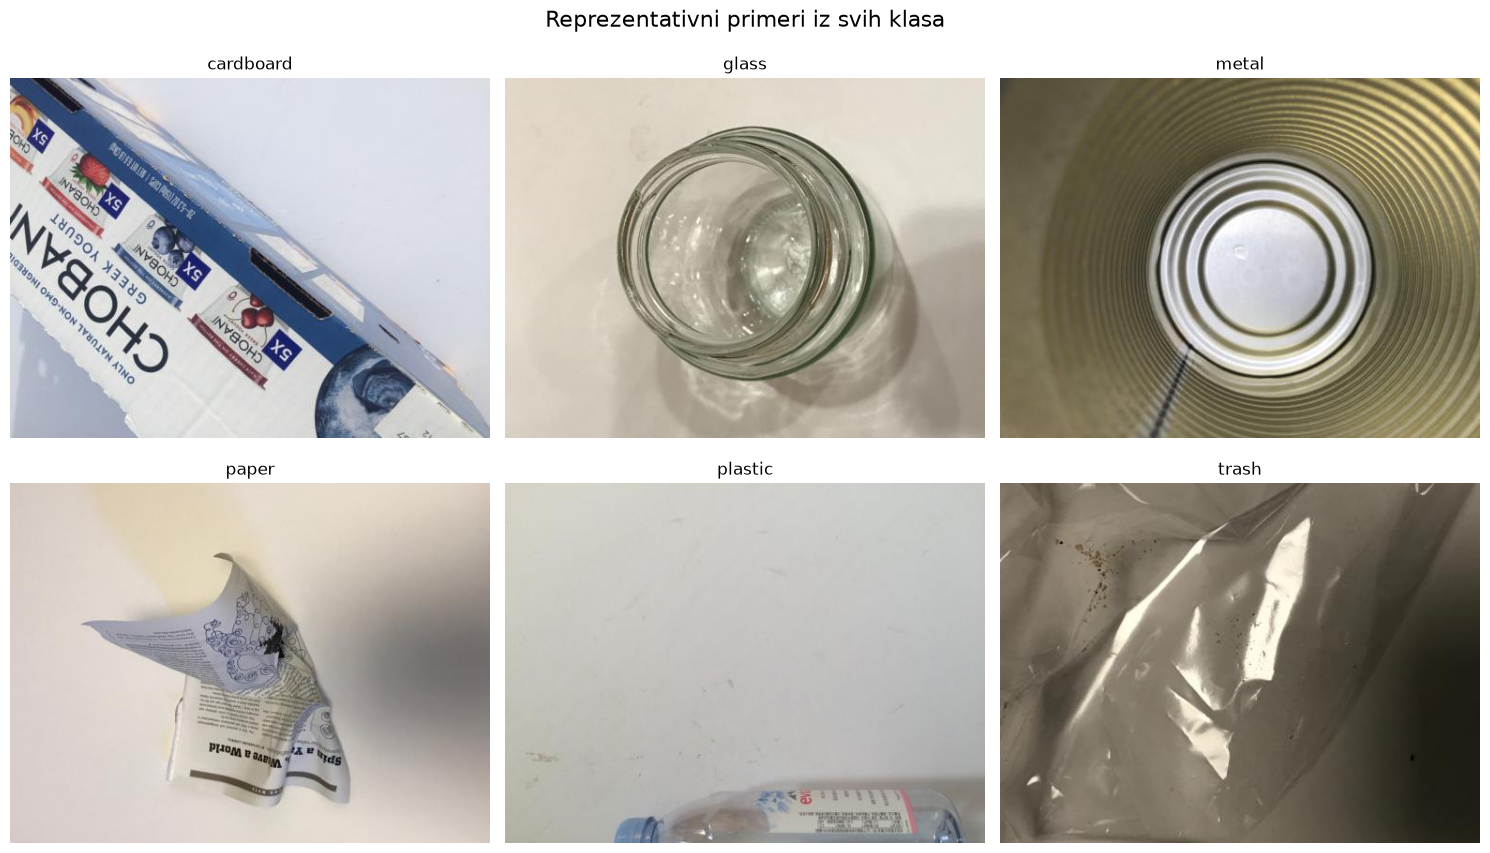

In [18]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

for ax, class_name in zip(axes.ravel(), classes):
    class_images = df[df["class"] == class_name]

    sample = class_images.sample(
        n=1,
        random_state=SEED
    ).iloc[0]

    with Image.open(sample["filepath"]) as img:
        ax.imshow(img.convert("RGB"))

    ax.set_title(class_name)
    ax.axis("off")

plt.suptitle(
    "Reprezentativni primeri iz svih klasa",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [19]:
def calculate_md5(filepath):
    hash_md5 = hashlib.md5()

    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()


hashes = []

for filepath in df["filepath"]:
    try:
        hashes.append(calculate_md5(filepath))
    except Exception:
        hashes.append(None)

df["md5"] = hashes

duplicate_groups = (
    df[df["md5"].notna()]
    .groupby("md5")
    .filter(lambda group: len(group) > 1)
    .sort_values("md5")
)

print(
    f"Broj slika koje učestvuju u grupama duplikata: "
    f"{len(duplicate_groups)}"
)

if len(duplicate_groups) > 0:
    display(
        duplicate_groups[
            ["filename", "class", "filepath", "md5"]
        ].head(30)
    )
else:
    print("Nisu pronađeni potpuni duplikati.")

Broj slika koje učestvuju u grupama duplikata: 6


,filename,class,filepath,md5
421,glass115.jpg,glass,c:\Users\PC\Garbage-Classification\data\raw\Ga...,70df08c3ce6d55e25df4edbbe45e5fe3
1305,metal91.jpg,metal,c:\Users\PC\Garbage-Classification\data\raw\Ga...,70df08c3ce6d55e25df4edbbe45e5fe3
488,glass176.jpg,glass,c:\Users\PC\Garbage-Classification\data\raw\Ga...,a2236bc6f8eae80bf7d6c5f259df8760
1967,plastic152.jpg,plastic,c:\Users\PC\Garbage-Classification\data\raw\Ga...,a2236bc6f8eae80bf7d6c5f259df8760
724,glass389.jpg,glass,c:\Users\PC\Garbage-Classification\data\raw\Ga...,e52ec9a8f6089b5780728b148c9f795e
2167,plastic332.jpg,plastic,c:\Users\PC\Garbage-Classification\data\raw\Ga...,e52ec9a8f6089b5780728b148c9f795e


In [20]:
import sys

sys.path.append(str(PROJECT_ROOT / "src"))

from data_pipeline import (
    find_dataset_root,
    discover_images,
    validate_images,
)

In [21]:
dataset_root = find_dataset_root(PROJECT_ROOT)

print("Dataset root:")
print(dataset_root)

Dataset root:
c:\Users\PC\Garbage-Classification\data\raw\Garbage classification\Garbage classification


In [22]:
pipeline_df = discover_images(dataset_root)

print(f"Pronađeno slika: {len(pipeline_df):,}")

display(pipeline_df.head())

Pronađeno slika: 2,527


,filepath,filename,class,extension
0,c:\Users\PC\Garbage-Classification\data\raw\Ga...,cardboard1.jpg,cardboard,.jpg
1,c:\Users\PC\Garbage-Classification\data\raw\Ga...,cardboard10.jpg,cardboard,.jpg
2,c:\Users\PC\Garbage-Classification\data\raw\Ga...,cardboard100.jpg,cardboard,.jpg
3,c:\Users\PC\Garbage-Classification\data\raw\Ga...,cardboard101.jpg,cardboard,.jpg
4,c:\Users\PC\Garbage-Classification\data\raw\Ga...,cardboard102.jpg,cardboard,.jpg


In [23]:
valid_df, invalid_df = validate_images(pipeline_df)

print(f"Validne slike: {len(valid_df):,}")
print(f"Nevalidne slike: {len(invalid_df):,}")

Validne slike: 2,527
Nevalidne slike: 0


In [24]:
from pathlib import Path

raw_dir = PROJECT_ROOT / "data" / "raw"

txt_files = sorted(raw_dir.glob("*.txt"))

for file in txt_files:
    print(f"\n--- {file.name} ---")
    
    with open(file, "r", encoding="utf-8") as f:
        lines = f.readlines()
    
    print(f"Broj redova: {len(lines):,}")
    print("Prvih 5 redova:")
    
    for line in lines[:5]:
        print(line.strip())


--- one-indexed-files-notrash_test.txt ---
Broj redova: 431
Prvih 5 redova:
paper70.jpg 2
paper380.jpg 2
cardboard31.jpg 3
glass12.jpg 1
paper169.jpg 2

--- one-indexed-files-notrash_train.txt ---
Broj redova: 1,768
Prvih 5 redova:
cardboard202.jpg 3
paper472.jpg 2
paper522.jpg 2
glass189.jpg 1
glass325.jpg 1

--- one-indexed-files-notrash_val.txt ---
Broj redova: 328
Prvih 5 redova:
cardboard114.jpg 3
plastic204.jpg 4
glass123.jpg 1
glass152.jpg 1
glass398.jpg 1

--- one-indexed-files.txt ---
Broj redova: 2,527
Prvih 5 redova:
glass1.jpg 1
glass2.jpg 1
glass3.jpg 1
glass4.jpg 1
glass5.jpg 1

--- zero-indexed-files.txt ---
Broj redova: 2,527
Prvih 5 redova:
glass1.jpg 0
glass2.jpg 0
glass3.jpg 0
glass4.jpg 0
glass5.jpg 0


In [25]:
#PROVERA SPLITOVA

from pathlib import Path
import pandas as pd

raw_dir = PROJECT_ROOT / "data" / "raw"

split_files = {
    "train": raw_dir / "one-indexed-files-notrash_train.txt",
    "val": raw_dir / "one-indexed-files-notrash_val.txt",
    "test": raw_dir / "one-indexed-files-notrash_test.txt",
}

split_data = {}

for split_name, file_path in split_files.items():
    rows = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) >= 2:
                filename = parts[0]
                label = int(parts[1])

                rows.append({
                    "filename": filename,
                    "label": label,
                    "split": split_name
                })

    split_data[split_name] = pd.DataFrame(rows)

    print(
        f"{split_name.upper():5s}: "
        f"{len(split_data[split_name]):,} zapisa"
    )

TRAIN: 1,768 zapisa
VAL  : 328 zapisa
TEST : 431 zapisa


In [26]:
#PROVERA PREKLAPANJA
train_files = set(split_data["train"]["filename"])
val_files = set(split_data["val"]["filename"])
test_files = set(split_data["test"]["filename"])

print("Train ∩ Validation:", len(train_files & val_files))
print("Train ∩ Test:", len(train_files & test_files))
print("Validation ∩ Test:", len(val_files & test_files))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [27]:
class_to_index = {
    class_name: index
    for index, class_name in enumerate(classes)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

print("Mapiranje klasa:")

for index, class_name in index_to_class.items():
    print(f"{index} -> {class_name}")

Mapiranje klasa:
0 -> cardboard
1 -> glass
2 -> metal
3 -> paper
4 -> plastic
5 -> trash


In [ ]:
#REZULTATI ZA SPLIT DATASET
import sys

sys.path.append(str(PROJECT_ROOT / "src"))

from split_dataset import (
    load_fixed_splits,
    create_cv_dataset,
    create_stratified_folds,
    validate_folds,
)

raw_dir = PROJECT_ROOT / "data" / "raw"

train_df, val_df, test_df = load_fixed_splits(raw_dir)

print(f"TRAIN: {len(train_df):,}")
print(f"VAL:   {len(val_df):,}")
print(f"TEST:  {len(test_df):,}")

cv_df = create_cv_dataset(train_df, val_df)

print(f"\nCV dataset: {len(cv_df):,}")

cv_df = create_stratified_folds(cv_df)

print("\nBroj uzoraka po foldu:")
print(cv_df["fold"].value_counts().sort_index())

print("\nProvera foldova:")
print(validate_folds(cv_df))

TRAIN: 1,768
VAL:   328
TEST:  431

CV dataset: 2,096

Broj uzoraka po foldu:
fold
0    420
1    419
2    419
3    419
4    419
Name: count, dtype: int64

Provera foldova:
True
